In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import ortho_group
from sklearn.metrics import adjusted_rand_score
import matplotlib.lines as mlines
import matplotlib.cm as cm

In [ ]:
seed = 42
np.random.seed(seed)
plt.rc('font', size=15)
plt.rc('axes', titlesize=18)
plt.rc('axes', labelsize=15)
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)
plt.rc('legend', fontsize=14)
plt.rc('legend', title_fontsize=14)

## Tandem Failure

c:\Users\mkhus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mkhus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


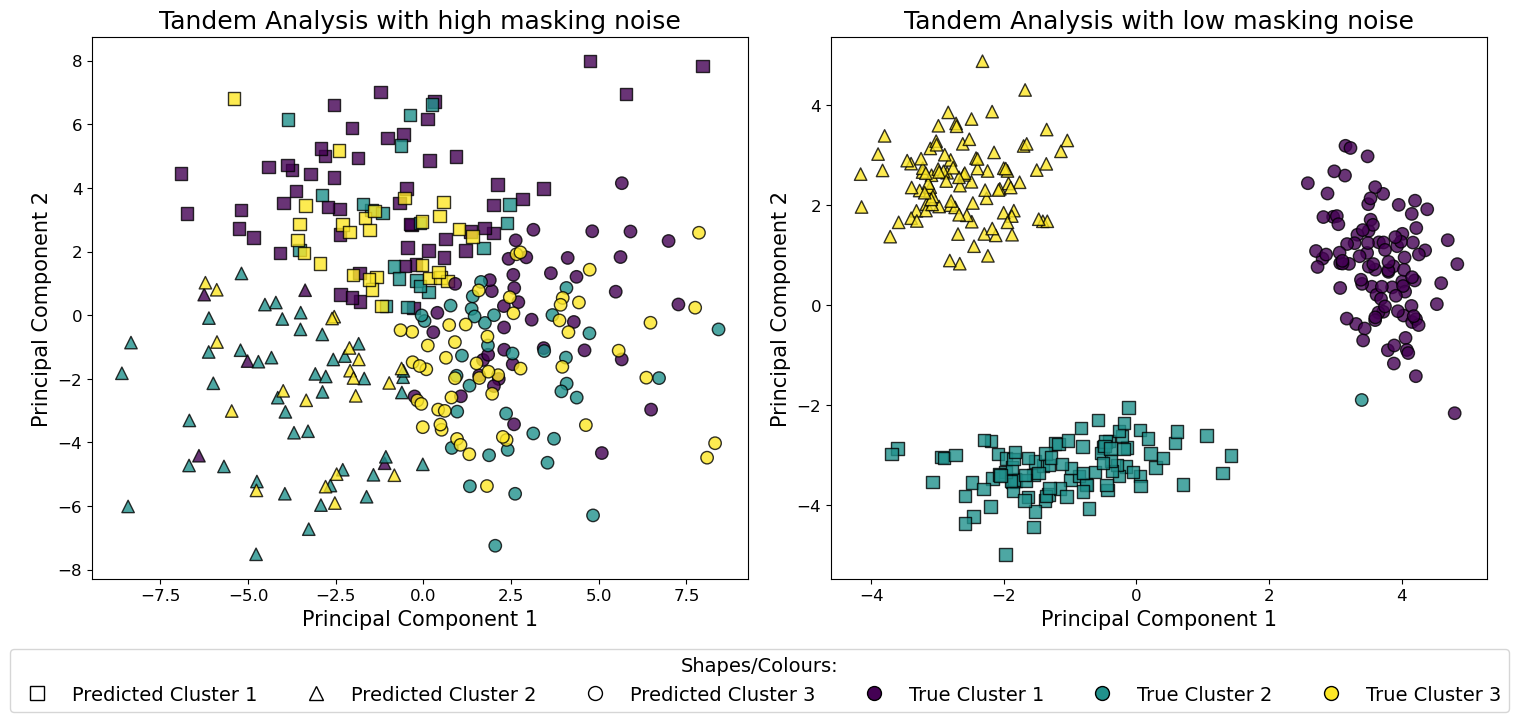

High masking PCA loading matrix:
[[ 0.0923  0.0937]
 [ 0.0916  0.4111]
 [-0.1578  0.1238]
 [ 0.707  -0.2729]
 [ 0.314  -0.1191]
 [-0.4738 -0.3747]
 [ 0.2965  0.5046]
 [-0.2175  0.5685]]
ARI - 0.06991374689261827
Low masking PCA loading matrix:
[[-0.237   0.9698]
 [ 0.9707  0.2376]
 [ 0.0043 -0.0215]
 [ 0.0041 -0.0379]
 [-0.0046  0.0173]
 [ 0.0032  0.0199]
 [ 0.0265  0.0056]
 [ 0.028  -0.0223]]
ARI - 0.9899831669528851


In [12]:
# Fix parameters
N=300
K, L, P = 3, 2, 8
sigma, sigma_high, sigma_low = 1, 3, 1


# True Centroids
centroids = np.array([
    [ 0.0,  np.sqrt(13)],
    [-3.0, -2.0],
    [ 3.0, -2.0]
])

# Define covariance matrix
stds = np.sqrt(np.array([
    [1.5, 0.2],  # Horizontally stretched
    [0.2, 1.5],  # Vertically stretched
    [0.5, 0.5]   # Spherical
]))

# True cluster data
true_labels = np.repeat(np.arange(K), N // K)
X = centroids[true_labels] + np.random.normal(loc=0.0, scale=sigma, size=(N, L)) * stds[true_labels]

# High and zero variance masking
high_noise = np.random.normal(loc=0.0, scale=sigma_high, size=(N, P-L))
low_noise = np.random.normal(loc=0.0, scale=sigma_low, size=(N, P-L))

# Rotate data matrix
#rotation_matrix = ortho_group.rvs(dim=(P), random_state=seed)
rotation_matrix = np.eye(P)

X_high_noise = np.dot(np.hstack([X, high_noise]), rotation_matrix)
X_low_noise = np.dot(np.hstack([X, low_noise]), rotation_matrix)

# Tandem analsyis + ARI computation
pca_high_noise = PCA(n_components=L)
X_pca_high = pca_high_noise.fit_transform(X_high_noise)
preds_high_noise = KMeans(n_clusters=K, random_state=seed, n_init=10).fit_predict(X_pca_high)
ari_high_noise = adjusted_rand_score(true_labels, preds_high_noise)

pca_low_noise = PCA(n_components=L)
X_pca_low = pca_low_noise.fit_transform(X_low_noise)
preds_low_noise = KMeans(n_clusters=K, random_state=seed, n_init=10).fit_predict(X_pca_low)
ari_low_noise = adjusted_rand_score(true_labels, preds_low_noise)

# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
markers = ['s', '^', 'o']
cmap = cm.viridis

# Plot 1
for pred_lbl in range(K):
    idx = (preds_high_noise == pred_lbl)
    ax1.scatter(
        X_pca_high[idx, 0], X_pca_high[idx, 1], 
        c=true_labels[idx], cmap='viridis', 
        marker=markers[pred_lbl], edgecolor='k', 
        s=80, alpha=0.8, vmin=0, vmax=K-1
    )
ax1.set_title(f'Tandem Analysis with high masking noise')#\nARI = {ari_high_noise:.4f}')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')

# Plot 2
for pred_lbl in range(K):
    idx = (preds_low_noise == pred_lbl)
    ax2.scatter(
        X_pca_low[idx, 0], X_pca_low[idx, 1], 
        c=true_labels[idx], cmap='viridis', 
        marker=markers[pred_lbl], edgecolor='k', 
        s=80, alpha=0.8, vmin=0, vmax=K-1
    )
ax2.set_title(f'Tandem Analysis with low masking noise')#\nARI = {ari_low_noise:.4f}')
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')

# Legend at bottom
legend_elements = [
    mlines.Line2D([], [], color='none', marker='s', markeredgecolor='k', markerfacecolor='w', markersize=10, label='Predicted Cluster 1'),
    mlines.Line2D([], [], color='none', marker='^', markeredgecolor='k', markerfacecolor='w', markersize=10, label='Predicted Cluster 2'),
    mlines.Line2D([], [], color='none', marker='o', markeredgecolor='k', markerfacecolor='w', markersize=10, label='Predicted Cluster 3'),
    mlines.Line2D([], [], color='none', marker='o', markeredgecolor='k', markerfacecolor=cmap(0.0), markersize=10, label='True Cluster 1'),
    mlines.Line2D([], [], color='none', marker='o', markeredgecolor='k', markerfacecolor=cmap(0.5), markersize=10, label='True Cluster 2'),
    mlines.Line2D([], [], color='none', marker='o', markeredgecolor='k', markerfacecolor=cmap(1.0), markersize=10, label='True Cluster 3')
]

fig.legend(handles=legend_elements, loc='lower center', ncol=6, bbox_to_anchor=(0.5, -0.05), title="Shapes/Colours:")

plt.tight_layout(rect=[0, 0.05, 1, 1]) 
plt.savefig('tandem_failure.pdf', bbox_inches='tight')
plt.show()

with np.printoptions(suppress=True, precision=4):
    print(f"High masking PCA loading matrix:\n{pca_high_noise.components_.T}\nARI - {ari_high_noise}")
    print(f"Low masking PCA loading matrix:\n{pca_low_noise.components_.T}\nARI - {ari_low_noise}")

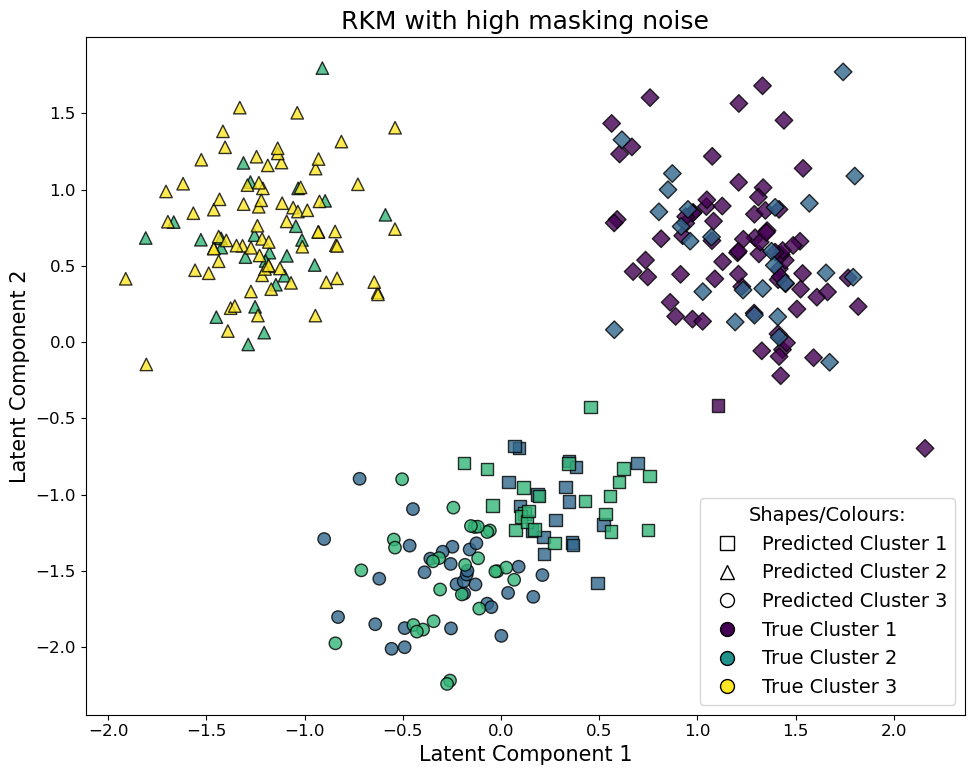

RKM loading matrix:
[[-0.4724  0.8604]
 [ 0.8611  0.4513]
 [ 0.0971 -0.0822]
 [-0.0101  0.027 ]
 [ 0.0592 -0.0127]
 [-0.043  -0.1726]
 [ 0.1195  0.1158]
 [ 0.0782  0.0717]]
ARI - 0.4892927822484339


In [ ]:
from base import RKM

# Intialise and fit RKM model onto noisy data
rkm_model = RKM(K=K, L=L, Rndstate=seed)
rkm_model.fit(X_high_noise)
# Exctract predicitons
if rkm_model.U.ndim > 1:
    preds_rkm = np.argmax(rkm_model.U, axis=1)
else:
    preds_rkm = rkm_model.U.flatten()

# Project and compute ARI
X_rkm_proj = rkm_model.zscore(X_high_noise) @ rkm_model.A
ari_rkm = adjusted_rand_score(true_labels, preds_rkm)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

for pred_lbl in range(K):
    idx = (preds_rkm == pred_lbl)
    ax.scatter(
        X_rkm_proj[idx, 0], X_rkm_proj[idx, 1], 
        c=true_labels[idx], cmap='viridis', 
        marker=markers[pred_lbl], edgecolor='k', 
        s=80, alpha=0.8, vmin=0, vmax=K-1
    )

ax.set_title('RKM with high masking noise')
ax.set_xlabel('Latent Component 1')
ax.set_ylabel('Latent Component 2')

# Legend
legend_elements_rkm = [
    mlines.Line2D([], [], color='none', marker='s', markeredgecolor='k', markerfacecolor='w', markersize=10, label='Predicted Cluster 1'),
    mlines.Line2D([], [], color='none', marker='^', markeredgecolor='k', markerfacecolor='w', markersize=10, label='Predicted Cluster 2'),
    mlines.Line2D([], [], color='none', marker='o', markeredgecolor='k', markerfacecolor='w', markersize=10, label='Predicted Cluster 3'),
    mlines.Line2D([], [], color='none', marker='o', markeredgecolor='k', markerfacecolor=cmap(0.0), markersize=10, label='True Cluster 1'),
    mlines.Line2D([], [], color='none', marker='o', markeredgecolor='k', markerfacecolor=cmap(0.5), markersize=10, label='True Cluster 2'),
    mlines.Line2D([], [], color='none', marker='o', markeredgecolor='k', markerfacecolor=cmap(1.0), markersize=10, label='True Cluster 3')
]

ax.legend(handles=legend_elements_rkm, loc='best', title="Shapes/Colours:")

plt.tight_layout()
plt.savefig('tandem_failure_RKM.pdf', bbox_inches='tight')
plt.show()

with np.printoptions(suppress=True, precision=4):
    print(f"RKM loading matrix:\n{rkm_model.A}\nARI - {ari_rkm}")

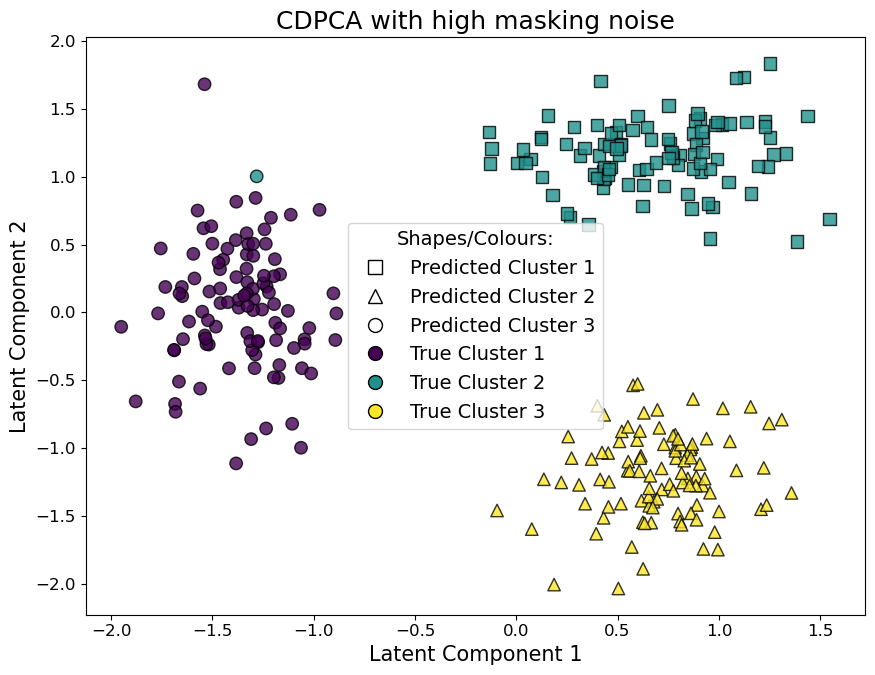

CDPCA loading matrix:
[[ 0.     -0.9855]
 [-0.9911  0.    ]
 [ 0.      0.1205]
 [ 0.     -0.0249]
 [-0.0623  0.    ]
 [ 0.      0.1168]
 [-0.0895  0.    ]
 [-0.077   0.    ]]
ARI - 0.9899831669528851


In [14]:
from base import CDPCA

# Intialise and fit CDPCA model onto noisy data
CDPCA_model = CDPCA(K=K, L=L, Rndstate=seed)
CDPCA_model.fit(X_high_noise)
# Exctract predicitons
if CDPCA_model.U.ndim > 1:
    preds_CDPCA = np.argmax(CDPCA_model.U, axis=1)
else:
    preds_CDPCA = CDPCA_model.U.flatten()

# Project and compute ARI
X_CDPCA_proj = CDPCA_model.zscore(X_high_noise) @ CDPCA_model.A
ari_CDPCA = adjusted_rand_score(true_labels, preds_CDPCA)

# Plot
fig, ax = plt.subplots(figsize=(9, 7))

for pred_lbl in range(K):
    idx = (preds_CDPCA == pred_lbl)
    ax.scatter(
        X_CDPCA_proj[idx, 0], X_CDPCA_proj[idx, 1], 
        c=true_labels[idx], cmap='viridis', 
        marker=markers[pred_lbl], edgecolor='k', 
        s=80, alpha=0.8, vmin=0, vmax=K-1
    )

ax.set_title(f'CDPCA with high masking noise')
ax.set_xlabel('Latent Component 1')
ax.set_ylabel('Latent Component 2')

# Legend
legend_elements_CDPCA = [
    mlines.Line2D([], [], color='none', marker='s', markeredgecolor='k', markerfacecolor='w', markersize=10, label='Predicted Cluster 1'),
    mlines.Line2D([], [], color='none', marker='^', markeredgecolor='k', markerfacecolor='w', markersize=10, label='Predicted Cluster 2'),
    mlines.Line2D([], [], color='none', marker='o', markeredgecolor='k', markerfacecolor='w', markersize=10, label='Predicted Cluster 3'),
    mlines.Line2D([], [], color='none', marker='o', markeredgecolor='k', markerfacecolor=cmap(0.0), markersize=10, label='True Cluster 1'),
    mlines.Line2D([], [], color='none', marker='o', markeredgecolor='k', markerfacecolor=cmap(0.5), markersize=10, label='True Cluster 2'),
    mlines.Line2D([], [], color='none', marker='o', markeredgecolor='k', markerfacecolor=cmap(1.0), markersize=10, label='True Cluster 3')
]

ax.legend(handles=legend_elements_CDPCA, loc='best', title="Shapes/Colours:")

plt.tight_layout()
plt.show()
print(f"CDPCA loading matrix:\n{np.round(CDPCA_model.A, 4)}\nARI - {ari_CDPCA}")

## Intepretability

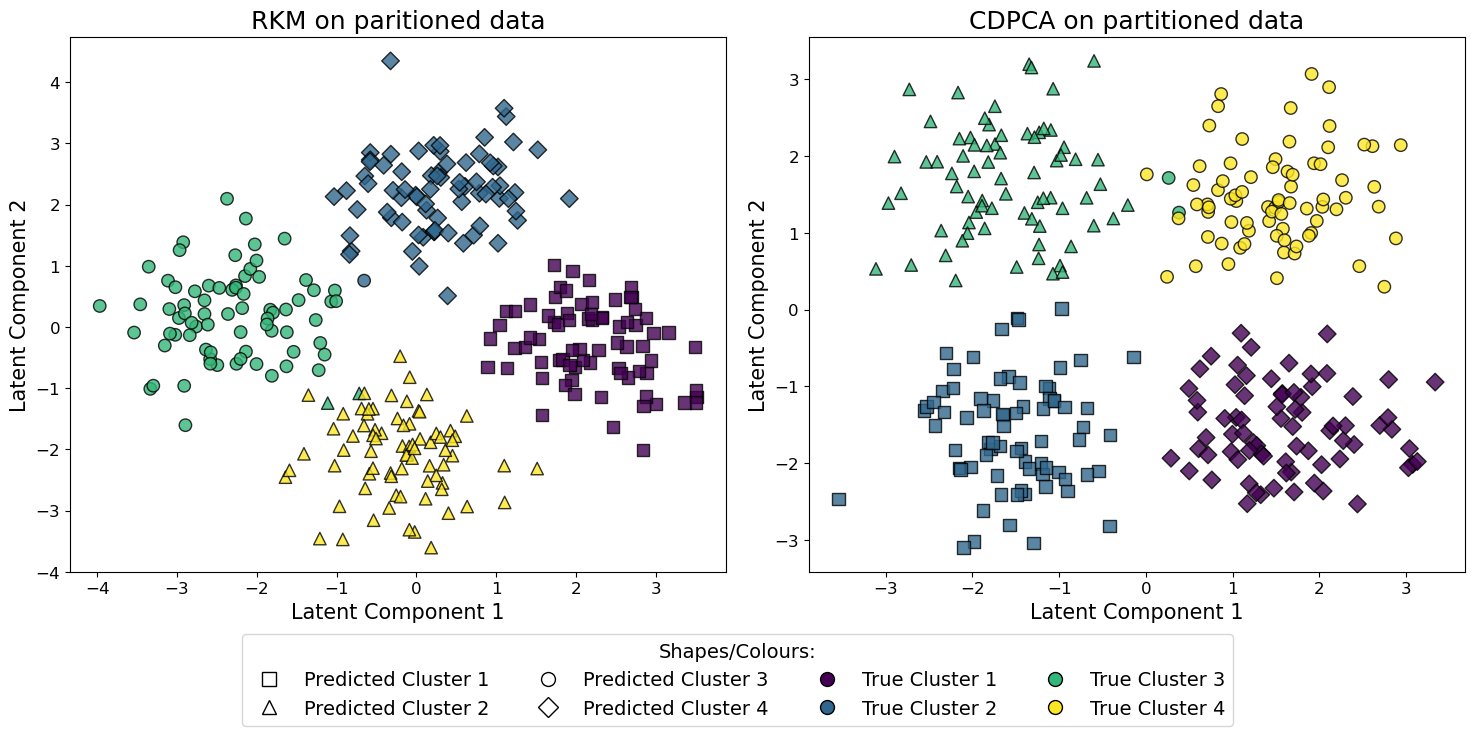

True loading matrix:
[[0.5 0. ]
 [0.5 0. ]
 [0.5 0. ]
 [0.5 0. ]
 [0.  0.5]
 [0.  0.5]
 [0.  0.5]
 [0.  0.5]]

RKM loading matrix:
[[ 0.3289 -0.3799]
 [ 0.3332 -0.3726]
 [ 0.2961 -0.3898]
 [ 0.2971 -0.413 ]
 [ 0.4125  0.3073]
 [ 0.3936  0.3028]
 [ 0.3759  0.3173]
 [ 0.3722  0.3278]]
ARI - 0.9734844867922889

CDPCA loading matrix:
[[ 0.5035  0.    ]
 [ 0.5008  0.    ]
 [ 0.4887  0.    ]
 [ 0.5068  0.    ]
 [ 0.     -0.5136]
 [ 0.     -0.4961]
 [ 0.     -0.492 ]
 [ 0.     -0.498 ]]
ARI - 0.9822836237620116


In [20]:
# Fix parameters
N = 300
K, L, P = 4, 2, 8

# True latent centroids
centroids = np.array([
    [2.5,  2.5], 
    [-2.5,  2.5], 
    [-2.5, -2.5], 
    [2.5, -2.5]  
])

# True cluster data
true_labels = np.repeat(np.arange(K), N // K)
latent_data = centroids[true_labels] + np.random.normal(0, 0.5, size=(N, L))

# Disjoint Loading Matrix
A_true = np.zeros((P, L))
A_true[0:4, 0] = 1.0 / np.sqrt(4)  # Vars 1-4 on on Latent Comp 1
A_true[4:8, 1] = 1.0 / np.sqrt(4)  # Vars 5-8 on on Latent Comp 2

# Project to ambient space and add noise
X = latent_data @ A_true.T + np.random.normal(0, 1, size=(N, P))

# RKM and CDPCA fits + ARI computation
rkm_model = RKM(K=K, L=L, Rndstate=seed).fit(X)
preds_rkm = np.argmax(rkm_model.U, axis=1) if rkm_model.U.ndim > 1 else rkm_model.U.flatten()
X_rkm_proj = rkm_model.zscore(X) @ rkm_model.A
ari_rkm = adjusted_rand_score(true_labels, preds_rkm)

cdpca_model = CDPCA(K=K, L=L, Rndstate=seed).fit(X)
preds_cdpca = np.argmax(cdpca_model.U, axis=1) if cdpca_model.U.ndim > 1 else cdpca_model.U.flatten()
X_cdpca_proj = cdpca_model.zscore(X) @ cdpca_model.A
ari_cdpca = adjusted_rand_score(true_labels, preds_cdpca)

# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
markers = ['s', '^', 'o', 'D']
cmap = cm.viridis

# Plot RKM
for pred_lbl in range(K):
    idx = (preds_rkm == pred_lbl)
    ax1.scatter(
        X_rkm_proj[idx, 0], X_rkm_proj[idx, 1], 
        c=true_labels[idx], cmap='viridis', 
        marker=markers[pred_lbl], edgecolor='k', 
        s=80, alpha=0.8, vmin=0, vmax=K-1
    )
ax1.set_title('RKM on paritioned data')
ax1.set_xlabel('Latent Component 1')
ax1.set_ylabel('Latent Component 2')

# Plot CDPCA
for pred_lbl in range(K):
    idx = (preds_cdpca == pred_lbl)
    ax2.scatter(
        X_cdpca_proj[idx, 0], X_cdpca_proj[idx, 1], 
        c=true_labels[idx], cmap='viridis', 
        marker=markers[pred_lbl], edgecolor='k', 
        s=80, alpha=0.8, vmin=0, vmax=K-1
    )
ax2.set_title('CDPCA on partitioned data')
ax2.set_xlabel('Latent Component 1')
ax2.set_ylabel('Latent Component 2')

# Legend at bottom
legend_elements = [
    mlines.Line2D([], [], color='none', marker='s', markeredgecolor='k', markerfacecolor='w', markersize=10, label='Predicted Cluster 1'),
    mlines.Line2D([], [], color='none', marker='^', markeredgecolor='k', markerfacecolor='w', markersize=10, label='Predicted Cluster 2'),
    mlines.Line2D([], [], color='none', marker='o', markeredgecolor='k', markerfacecolor='w', markersize=10, label='Predicted Cluster 3'),
    mlines.Line2D([], [], color='none', marker='D', markeredgecolor='k', markerfacecolor='w', markersize=10, label='Predicted Cluster 4'),
    mlines.Line2D([], [], color='none', marker='o', markeredgecolor='k', markerfacecolor=cmap(0.0), markersize=10, label='True Cluster 1'),
    mlines.Line2D([], [], color='none', marker='o', markeredgecolor='k', markerfacecolor=cmap(0.33), markersize=10, label='True Cluster 2'),
    mlines.Line2D([], [], color='none', marker='o', markeredgecolor='k', markerfacecolor=cmap(0.66), markersize=10, label='True Cluster 3'),
    mlines.Line2D([], [], color='none', marker='o', markeredgecolor='k', markerfacecolor=cmap(1.0), markersize=10, label='True Cluster 4')
]

fig.legend(handles=legend_elements, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.07), title="Shapes/Colours:")

plt.tight_layout(rect=[0, 0.06, 1, 1]) 
plt.savefig('rkm_cdpca_comp.pdf', bbox_inches='tight')
plt.show()

with np.printoptions(suppress=True, precision=4):
    print(f"True loading matrix:\n{A_true}\n")
    print(f"RKM loading matrix:\n{rkm_model.A}\nARI - {ari_rkm}\n")
    print(f"CDPCA loading matrix:\n{cdpca_model.A}\nARI - {ari_cdpca}")